In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# df = pd.read_csv("APPLE_PRODUCT_ANALYSIS\apple_products_pricing_2020_2026.csv")
df = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\power bi\\APPLE_PRODUCT_ANALYSIS\\apple_products_pricing_2020_2026.csv")
df["Date"] = pd.to_datetime(df["Date"])
print(df.dtypes)
print(df.describe())

Date                 datetime64[us]
Platform                        str
Product_Category                str
Model_Name                      str
Condition                       str
Launch_Price_USD              int64
Launch_Price_INR              int64
Current_Price_USD           float64
Current_Price_INR           float64
Discount_Pct                float64
Sale_Event                      str
Stock_Status                    str
Rating                      float64
Reviews_Count                 int64
dtype: object
                             Date  Launch_Price_USD  Launch_Price_INR  \
count                       80000      80000.000000      80000.000000   
mean   2024-09-14 22:14:06.360000        963.959125      94467.994250   
min           2020-09-19 00:00:00        329.000000      32242.000000   
25%           2023-11-03 00:00:00        599.000000      58702.000000   
50%           2024-12-22 00:00:00        799.000000      78302.000000   
75%           2025-10-27 00:00:00       1199

In [26]:

print(df.isnull().sum())
df["Sale_Event"] = df["Sale_Event"].fillna("NORMAL DAYS")
print(df["Sale_Event"].value_counts())



Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64
Sale_Event
NORMAL DAYS              73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64


In [27]:
print(df.dtypes)

Date                 datetime64[us]
Platform                        str
Product_Category                str
Model_Name                      str
Condition                       str
Launch_Price_USD              int64
Launch_Price_INR              int64
Current_Price_USD           float64
Current_Price_INR           float64
Discount_Pct                float64
Sale_Event                      str
Stock_Status                    str
Rating                      float64
Reviews_Count                 int64
dtype: object


In [28]:
platform_wise_pricing_with_product = df.groupby(["Platform","Product_Category","Model_Name"])[["Launch_Price_INR"]].mean()
print(platform_wise_pricing_with_product)

# df_flip_iphone_15 = df[(df["Platform"] == "Flipkart") & (df["Product_Category"] == "iPhone")  ][["Launch_Price_INR","Model_Name"]]
# print(df_flip_iphone_15)

                                                            Launch_Price_INR
Platform Product_Category Model_Name                                        
Amazon   Mac              MacBook Air M1 256GB                       97902.0
                          MacBook Air M2 256GB                      117502.0
                          MacBook Air M3 256GB                      107702.0
                          MacBook Pro 14-inch M1 Pro 512GB          195902.0
                          MacBook Pro 14-inch M2 Pro 512GB          195902.0
...                                                                      ...
Flipkart iPhone           iPhone 15 128GB                            78302.0
                          iPhone 15 Pro Max 256GB                   117502.0
                          iPhone 16 128GB                            78302.0
                          iPhone 16 Pro 256GB                       107702.0
                          iPhone 17 128GB                            83202.0

In [29]:
platform_wise_sales_count = df["Platform"].value_counts()
print("SALES OF EACH FLATFORM: ",platform_wise_sales_count)
platform_wise_pricing_ = df.groupby(["Platform","Product_Category"])[["Launch_Price_INR"]].count()
print(platform_wise_pricing_)


SALES OF EACH FLATFORM:  Platform
Flipkart    40043
Amazon      39957
Name: count, dtype: int64
                           Launch_Price_INR
Platform Product_Category                  
Amazon   Mac                           9083
         Watch                         8842
         iPad                          7788
         iPhone                       14244
Flipkart Mac                           8937
         Watch                         9023
         iPad                          7738
         iPhone                       14345


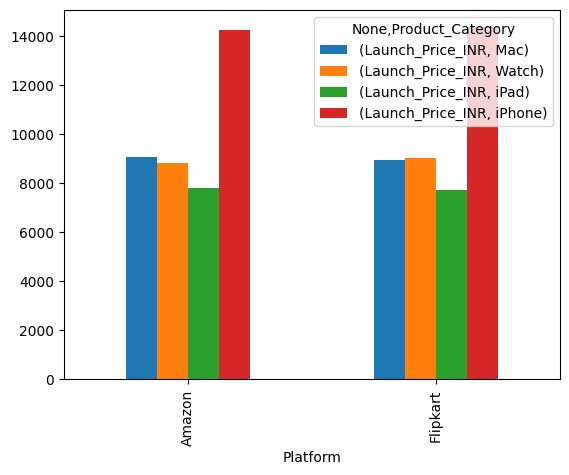

In [30]:
platform_wise_pricing_graph = df.groupby(["Platform","Product_Category"])[["Launch_Price_INR"]].count().unstack().plot(kind="bar")
plt.show()


In [31]:
# ,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR..

item_condition_wise_price = df.groupby(["Model_Name","Condition"])[["Launch_Price_INR"]].mean()
print(item_condition_wise_price)

# item_condition_wise_price.to_excel("MODEL_CONDITION_WISE_PRICE.xlsx") ##

                                                 Launch_Price_INR
Model_Name                  Condition                            
Apple Watch Series 6 (44mm) New                           42042.0
                            Renewed/Refurbished           42042.0
Apple Watch Series 7 (45mm) New                           42042.0
                            Renewed/Refurbished           42042.0
Apple Watch Series 8 (45mm) New                           42042.0
...                                                           ...
iPhone 16 128GB             Renewed/Refurbished           78302.0
iPhone 16 Pro 256GB         New                          107702.0
                            Renewed/Refurbished          107702.0
iPhone 17 128GB             New                           83202.0
                            Renewed/Refurbished           83202.0

[62 rows x 1 columns]


In [32]:
# SALE EVENT BY PRICE

print(df["Sale_Event"].value_counts())
which_sale_for_which_platform = df.groupby(["Platform","Sale_Event"])["Sale_Event"].count()
print(which_sale_for_which_platform)
sale_by_event_with_which_platform_revenue = df.groupby(["Platform","Model_Name","Sale_Event"])["Launch_Price_INR"].mean()
print(sale_by_event_with_which_platform_revenue)

Sale_Event
NORMAL DAYS              73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64
Platform  Sale_Event           
Amazon    Black Friday              1219
          Great Indian Festival     1504
          NORMAL DAYS              36165
          Prime Day                 1069
Flipkart  Big Billion Days          1579
          Black Friday              1278
          NORMAL DAYS              37186
Name: Sale_Event, dtype: int64
Platform  Model_Name                   Sale_Event           
Amazon    Apple Watch Series 6 (44mm)  Black Friday              42042.0
                                       Great Indian Festival     42042.0
                                       NORMAL DAYS               42042.0
                                       Prime Day                 42042.0
          Apple Watch Series 7 (45mm)  Black Friday              42042.0
                                

In [33]:
print(df["Launch_Price_INR"].value_counts())

Launch_Price_INR
78302     20512
42042     12828
97902     10463
195902    10271
117502    10217
58702      5260
107702     5224
83202      2652
32242      2573
Name: count, dtype: int64


In [34]:
# how much model is come from 2020-26 to all ios gadget

cat_model_type_count = df.groupby(["Product_Category","Model_Name"])["Launch_Price_INR"].mean()
print(cat_model_type_count)

Product_Category  Model_Name                      
Mac               MacBook Air M1 256GB                 97902.0
                  MacBook Air M2 256GB                117502.0
                  MacBook Air M3 256GB                107702.0
                  MacBook Pro 14-inch M1 Pro 512GB    195902.0
                  MacBook Pro 14-inch M2 Pro 512GB    195902.0
                  MacBook Pro 14-inch M3 Pro 512GB    195902.0
                  MacBook Pro 14-inch M4 Pro 512GB    195902.0
Watch             Apple Watch Series 6 (44mm)          42042.0
                  Apple Watch Series 7 (45mm)          42042.0
                  Apple Watch Series 8 (45mm)          42042.0
                  Apple Watch Series 9 (45mm)          42042.0
                  Apple Watch Series X (45mm)          42042.0
                  Apple Watch Ultra                    78302.0
                  Apple Watch Ultra 2                  78302.0
iPad              iPad (9th Gen) 64GB                  32242.0
    

In [35]:
platform_pivot = df.pivot_table(
    index=['Model_Name'],
    columns='Platform',
    values='Current_Price_USD',
    aggfunc='mean'
).round(2)
print(platform_pivot)

Platform                           Amazon  Flipkart
Model_Name                                         
Apple Watch Series 6 (44mm)        281.14    279.21
Apple Watch Series 7 (45mm)        290.35    282.66
Apple Watch Series 8 (45mm)        301.06    299.09
Apple Watch Series 9 (45mm)        320.76    316.76
Apple Watch Series X (45mm)        354.10    353.71
Apple Watch Ultra                  605.80    612.44
Apple Watch Ultra 2                646.42    657.93
MacBook Air M1 256GB               713.38    723.94
MacBook Air M2 256GB               972.64    970.63
MacBook Air M3 256GB               951.42    958.38
MacBook Pro 14-inch M1 Pro 512GB  1687.35   1685.54
MacBook Pro 14-inch M2 Pro 512GB  1747.91   1745.04
MacBook Pro 14-inch M3 Pro 512GB  1770.56   1781.62
MacBook Pro 14-inch M4 Pro 512GB  1823.00   1831.18
iPad (9th Gen) 64GB                215.75    214.16
iPad Air (4th Gen) 64GB            405.89    402.24
iPad Air (5th Gen) 64GB            419.26    423.49
iPad Pro 11-

In [36]:
product_wise_discount_by_platforms = df.pivot_table(
    index="Model_Name",
    columns="Platform",
    values="Discount_Pct",
    aggfunc="mean"
).round(3)
print(product_wise_discount_by_platforms)

Platform                          Amazon  Flipkart
Model_Name                                        
Apple Watch Series 6 (44mm)       34.466    34.917
Apple Watch Series 7 (45mm)       32.317    34.112
Apple Watch Series 8 (45mm)       29.824    30.284
Apple Watch Series 9 (45mm)       25.229    26.164
Apple Watch Series X (45mm)       17.459    17.548
Apple Watch Ultra                 24.181    23.350
Apple Watch Ultra 2               19.095    17.655
MacBook Air M1 256GB              28.592    27.533
MacBook Air M2 256GB              18.878    19.046
MacBook Air M3 256GB              13.428    12.796
MacBook Pro 14-inch M1 Pro 512GB  15.591    15.680
MacBook Pro 14-inch M2 Pro 512GB  12.561    12.703
MacBook Pro 14-inch M3 Pro 512GB  11.428    10.876
MacBook Pro 14-inch M4 Pro 512GB   8.804     8.396
iPad (9th Gen) 64GB               34.425    34.908
iPad Air (4th Gen) 64GB           32.240    32.847
iPad Air (5th Gen) 64GB           30.007    29.301
iPad Pro 11-inch (M1) 128GB    

In [57]:
# rating
# avg_rating_of_product_head = df.groupby("Model_Name").agg(
#     review_count=("Reviews_Count", "count"),
#     rating_avg=("Rating", "mean")
# ).sort_values(by="review_count",ascending=False).head(20)

# print(avg_rating_of_product_head)


# rating
avg_rating_of_product_tail = df.groupby("Model_Name").agg(
    review_count=("Reviews_Count", "count"),
    rating_avg=("Rating", "mean")
).sort_values(by="review_count",ascending=True).head(20)

print(avg_rating_of_product_tail)

                                  review_count  rating_avg
Model_Name                                                
iPad Pro 12.9-inch (M2) 256GB             2457    4.450916
Apple Watch Ultra 2                       2493    4.439029
iPhone 14 128GB                           2509    4.457114
Apple Watch Series X (45mm)               2520    4.440992
Apple Watch Series 9 (45mm)               2530    4.447391
iPhone 12 64GB                            2531    4.453220
Apple Watch Ultra                         2544    4.450432
MacBook Pro 14-inch M1 Pro 512GB          2545    4.445187
iPhone 13 Pro Max 256GB                   2547    4.442992
MacBook Pro 14-inch M3 Pro 512GB          2547    4.454927
MacBook Air M1 256GB                      2550    4.447804
MacBook Pro 14-inch M2 Pro 512GB          2556    4.446205
iPhone 16 128GB                           2567    4.452162
Apple Watch Series 6 (44mm)               2572    4.452100
iPad (9th Gen) 64GB                       2573    4.4502

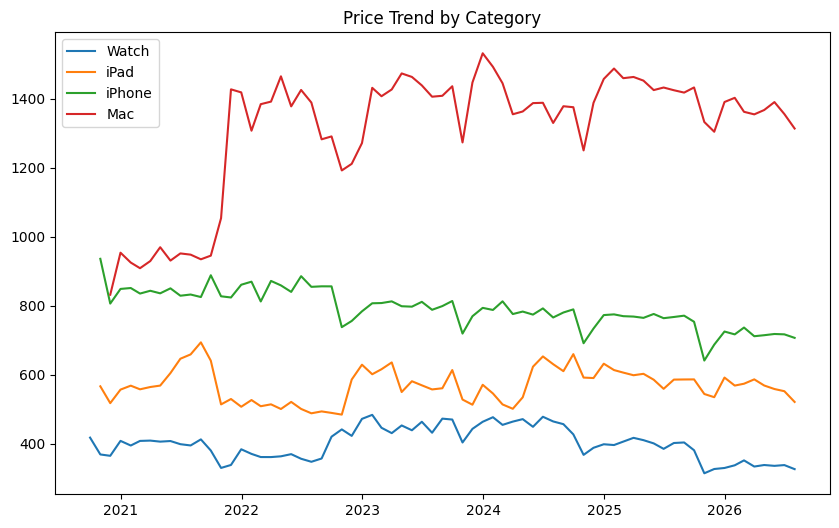

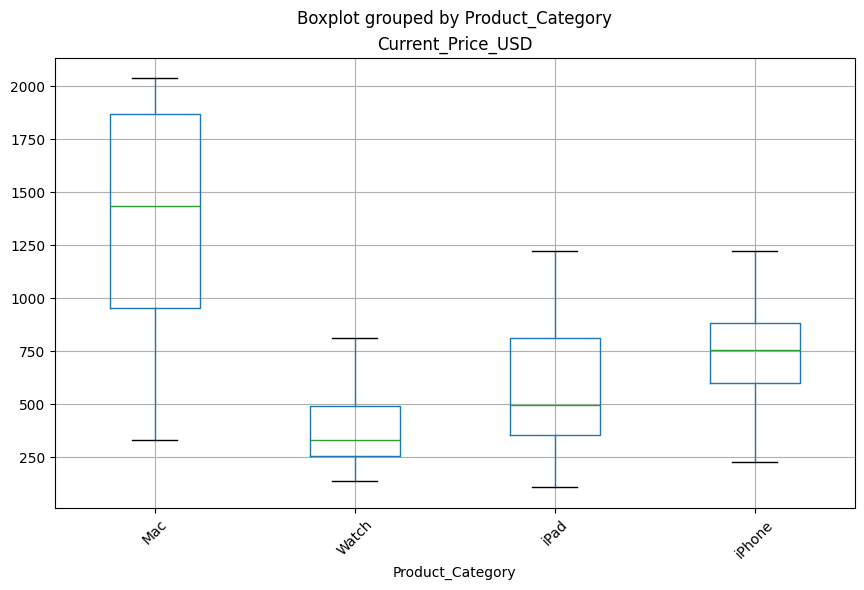

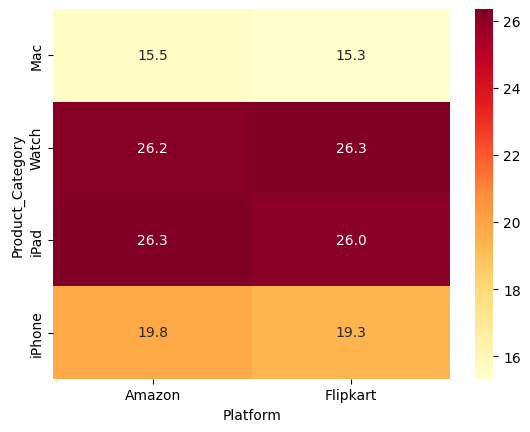

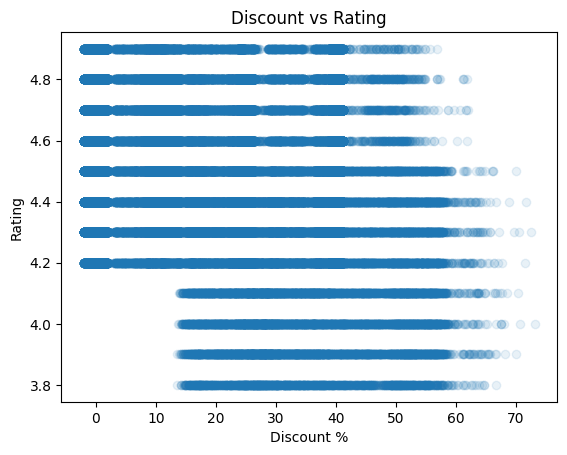

In [39]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

# Line chart: price trend over time by category
fig, ax = plt.subplots(figsize=(10,6))
for cat in df['Product_Category'].unique():
    sub = df[df['Product_Category']==cat].set_index('Date').resample('ME')['Current_Price_USD'].mean()
    ax.plot(sub.index, sub.values, label=cat)
ax.legend(); ax.set_title('Price Trend by Category'); plt.show()

# Boxplot: price distribution by category
df.boxplot(column='Current_Price_USD', by='Product_Category', figsize=(10,6), rot=45)
plt.show()

# Heatmap: platform x category discount
import seaborn as sns
heat_data = df.pivot_table(index='Product_Category', columns='Platform', values='Discount_Pct', aggfunc='mean')
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlOrRd')
plt.show()

# Scatter: discount vs rating
plt.scatter(df['Discount_Pct'], df['Rating'], alpha=0.1)
plt.xlabel('Discount %'); plt.ylabel('Rating'); plt.title('Discount vs Rating')
plt.show()